In [ ]:

file_path = r"/content/drive/MyDrive/alzheimers_disease_data.csv"

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
import pandas as pd
df = pd.read_csv(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [ ]:

df.isnull().sum()


,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


In [ ]:
df = df.dropna()


In [ ]:
df = pd.get_dummies(df, drop_first=True)


In [ ]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='object')

In [ ]:

X = df.drop(["PatientID", "Diagnosis"], axis=1)

y = df["Diagnosis"]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import joblib

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=150),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Machine": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)

    results[name] = acc
    trained_models[name] = model
    print("\n==============================")
    print(f"Model: {name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, predictions))



Model: Logistic Regression
Accuracy: 0.8302325581395349
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       277
           1       0.79      0.71      0.75       153

    accuracy                           0.83       430
   macro avg       0.82      0.80      0.81       430
weighted avg       0.83      0.83      0.83       430


Model: Decision Tree
Accuracy: 0.8953488372093024
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       277
           1       0.86      0.84      0.85       153

    accuracy                           0.90       430
   macro avg       0.89      0.88      0.88       430
weighted avg       0.89      0.90      0.89       430


Model: Random Forest
Accuracy: 0.9302325581395349
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       277
           1       0.96      0.84      0.90       153

    accuracy           

In [ ]:
results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

results_df.sort_values(by="Accuracy", ascending=False)


,Model,Accuracy
3,Gradient Boosting,0.958140
2,Random Forest,0.930233
1,Decision Tree,0.895349
4,Support Vector Machine,0.832558
0,Logistic Regression,0.830233
5,KNN,0.718605


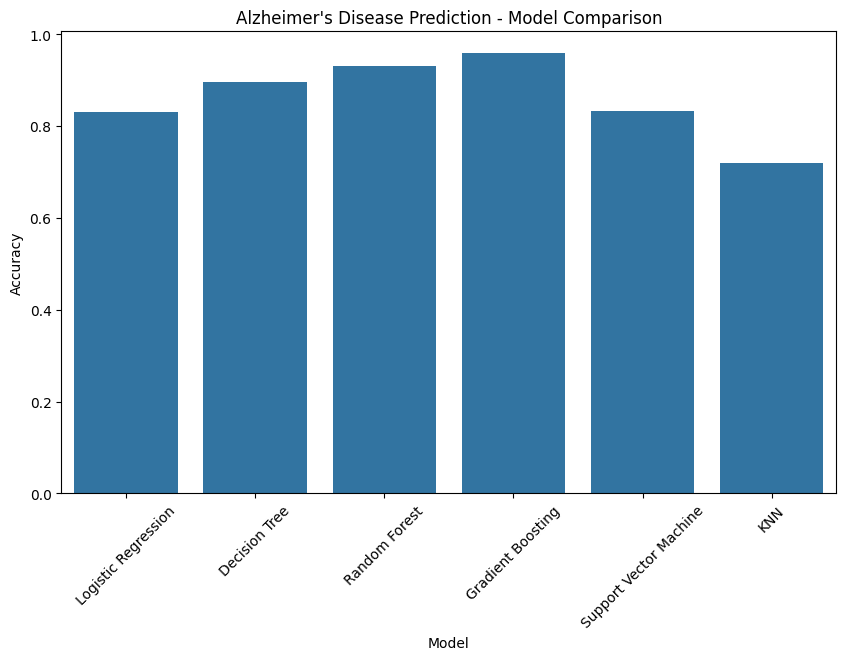

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.xticks(rotation=45)
plt.title("Alzheimer's Disease Prediction - Model Comparison")
plt.show()

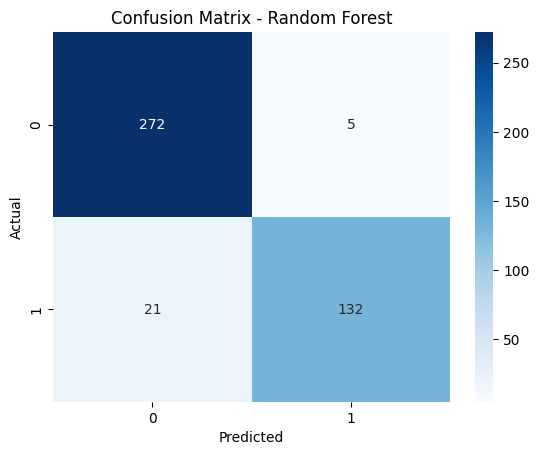

In [ ]:
from sklearn.metrics import confusion_matrix

best_model = RandomForestClassifier(n_estimators=150)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# save best model automatically
best_model_name = max(results, key=results.get)
joblib.dump(trained_models[best_model_name], "model.pkl")

print("Saved:", best_model_name)

Saved: Gradient Boosting


In [ ]:
sample_input = {
    "Age": 72,
    "Gender": 1,
    "Ethnicity": 2,
    "EducationLevel": 3,
    "BMI": 24.5,
    "Smoking": 0,
    "AlcoholConsumption": 1.2,
    "PhysicalActivity": 3.5,
    "DietQuality": 6.8,
    "SleepQuality": 7.0,
    "FamilyHistoryAlzheimers": 1,
    "CardiovascularDisease": 0,
    "Diabetes": 0,
    "Depression": 0,
    "HeadInjury": 0,
    "Hypertension": 1,
    "SystolicBP": 138,
    "DiastolicBP": 88,
    "CholesterolTotal": 210.0,
    "CholesterolLDL": 135.0,
    "CholesterolHDL": 48.0,
    "CholesterolTriglycerides": 170.0,
    "MMSE": 22.0,
    "FunctionalAssessment": 6.5,
    "MemoryComplaints": 1,
    "BehavioralProblems": 0,
    "ADL": 4.0,
    "Confusion": 1,
    "Disorientation": 0,
    "PersonalityChanges": 0,
    "DifficultyCompletingTasks": 1,
    "Forgetfulness": 1
}


In [ ]:
import pandas as pd
import joblib

model = joblib.load("model.pkl")


patient_df = pd.DataFrame([sample_input])[X.columns]


In [ ]:
prediction = model.predict(patient_df)
print("Prediction:", prediction[0])

Prediction: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


In [ ]:
len(sample_input)

32

In [ ]:

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier

from imblearn.over_sampling import SMOTE

# Load dataset
data = pd.read_csv("/content/drive/MyDrive/alzheimers_disease_data.csv")

print("Original Shape:", data.shape)

# Remove non numeric columns
data = data.select_dtypes(include=['int64','float64'])

print("After cleaning:", data.shape)

# Target column
target = "Diagnosis"

X = data.drop(columns=[target])
y = data[target]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Balance dataset
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before balance:")
print(y_train.value_counts())

print("After balance:")
print(pd.Series(y_train_bal).value_counts())

# Train model
model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train_bal, y_train_bal)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Save model
joblib.dump(model, "alzheimers_gradient_boost.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved")

Original Shape: (2149, 35)
After cleaning: (2149, 34)
Before balance:
Diagnosis
0    1112
1     607
Name: count, dtype: int64
After balance:
Diagnosis
0    1112
1    1112
Name: count, dtype: int64
Accuracy: 0.9674418604651163
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       277
           1       0.96      0.95      0.95       153

    accuracy                           0.97       430
   macro avg       0.97      0.96      0.96       430
weighted avg       0.97      0.97      0.97       430

Model saved


In [ ]:
print(X.columns)

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness'],
      dtype='object')


In [ ]:
sample_input = {

    "PatientID": 1001,
    "Age": 72,
    "Gender": 1,
    "Ethnicity": 2,
    "EducationLevel": 3,
    "BMI": 24.5,
    "Smoking": 0,
    "AlcoholConsumption": 1.2,
    "PhysicalActivity": 3.5,
    "DietQuality": 6.8,
    "SleepQuality": 7.0,
    "FamilyHistoryAlzheimers": 1,
    "CardiovascularDisease": 0,
    "Diabetes": 0,
    "Depression": 0,
    "HeadInjury": 0,
    "Hypertension": 1,
    "SystolicBP": 138,
    "DiastolicBP": 88,
    "CholesterolTotal": 210.0,
    "CholesterolLDL": 135.0,
    "CholesterolHDL": 48.0,
    "CholesterolTriglycerides": 170.0,
    "MMSE": 22.0,
    "FunctionalAssessment": 6.5,
    "MemoryComplaints": 1,
    "BehavioralProblems": 0,
    "ADL": 4.0,
    "Confusion": 1,
    "Disorientation": 0,
    "PersonalityChanges": 0,
    "DifficultyCompletingTasks": 1,
    "Forgetfulness": 1
}

In [ ]:
import joblib
import pandas as pd

model = joblib.load("alzheimers_gradient_boost.pkl")
scaler = joblib.load("scaler.pkl")

input_df = pd.DataFrame([sample_input])

scaled_input = scaler.transform(input_df)

prediction = model.predict(scaled_input)
prob = model.predict_proba(scaled_input)

print("Prediction:", prediction[0])
print("Confidence:", prob[0][prediction[0]])

if prediction == 1:
    print("Result: Alzheimer Disease Detected")
else:
    print("Result: No Alzheimer Disease")

Prediction: 1
Confidence: 0.9227763606165285
Result: Alzheimer Disease Detected


In [ ]:
import joblib
import pandas as pd

sample_input = {

    "PatientID": 2001,
    "Age": 65,
    "Gender": 0,
    "Ethnicity": 1,
    "EducationLevel": 4,
    "BMI": 23.0,
    "Smoking": 0,
    "AlcoholConsumption": 0.5,
    "PhysicalActivity": 4.5,
    "DietQuality": 8.5,
    "SleepQuality": 8.0,
    "FamilyHistoryAlzheimers": 0,
    "CardiovascularDisease": 0,
    "Diabetes": 0,
    "Depression": 0,
    "HeadInjury": 0,
    "Hypertension": 0,
    "SystolicBP": 120,
    "DiastolicBP": 80,
    "CholesterolTotal": 180.0,
    "CholesterolLDL": 100.0,
    "CholesterolHDL": 60.0,
    "CholesterolTriglycerides": 120.0,
    "MMSE": 29.0,
    "FunctionalAssessment": 9.0,
    "MemoryComplaints": 0,
    "BehavioralProblems": 0,
    "ADL": 9.0,
    "Confusion": 0,
    "Disorientation": 0,
    "PersonalityChanges": 0,
    "DifficultyCompletingTasks": 0,
    "Forgetfulness": 0
}

model = joblib.load("alzheimers_gradient_boost.pkl")
scaler = joblib.load("scaler.pkl")

input_df = pd.DataFrame([sample_input])

scaled_input = scaler.transform(input_df)

prediction = model.predict(scaled_input)
prob = model.predict_proba(scaled_input)

print("Prediction:", prediction[0])
print("Confidence:", prob[0][prediction[0]])

if prediction == 1:
    print("Result: Alzheimer Disease Detected")
else:
    print("Result: No Alzheimer Disease")

Prediction: 0
Confidence: 0.9994483481286345
Result: No Alzheimer Disease


In [ ]:

import pandas as pd
import numpy as np

from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import jaccard_score



path = "/content/drive/MyDrive/alzheimers_disease_data.csv"
df = pd.read_csv(path)

print("Dataset Shape:", df.shape)


df = df.drop(columns=["PatientID","DoctorInCharge"], errors="ignore")


target = "Diagnosis"

X = df.drop(target, axis=1)
y = df[target]

feature_names = np.array(X.columns)

print("\nTotal Features:", len(feature_names))



scaler = MinMaxScaler()
X_chi = scaler.fit_transform(X)

chi_selector = SelectKBest(score_func=chi2, k=15)
chi_selector.fit(X_chi, y)

chi_features = feature_names[chi_selector.get_support()]




pearson_scores = X.corrwith(y).abs()

pearson_features = (
    pearson_scores
    .sort_values(ascending=False)
    .head(15)
    .index
    .tolist()
)


mi_selector = SelectKBest(score_func=mutual_info_classif, k=15)

mi_selector.fit(X, y)

mi_features = feature_names[mi_selector.get_support()]


anova_selector = SelectKBest(score_func=f_classif, k=15)

anova_selector.fit(X, y)

anova_features = feature_names[anova_selector.get_support()]



X_binary = X.copy()

# Convert to binary
for col in X_binary.columns:
    X_binary[col] = (X_binary[col] > X_binary[col].median()).astype(int)

jaccard_scores = {}

for col in X_binary.columns:
    jaccard_scores[col] = jaccard_score(y, X_binary[col])

jaccard_features = sorted(
    jaccard_scores,
    key=jaccard_scores.get,
    reverse=True
)[:15]


print("\n==============================")

print("\nTop 15 Features - Chi Square")
print(list(chi_features))

print("\nTop 15 Features - Pearson")
print(pearson_features)

print("\nTop 15 Features - Information Gain")
print(list(mi_features))

print("\nTop 15 Features - ANOVA")
print(list(anova_features))

print("\nTop 15 Features - Jaccard")
print(jaccard_features)

print("\n==============================")

Dataset Shape: (2149, 35)

Total Features: 32


Top 15 Features - Chi Square
['EducationLevel', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'HeadInjury', 'Hypertension', 'CholesterolHDL', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Disorientation', 'PersonalityChanges']

Top 15 Features - Pearson
['FunctionalAssessment', 'ADL', 'MemoryComplaints', 'MMSE', 'BehavioralProblems', 'SleepQuality', 'EducationLevel', 'CholesterolHDL', 'Hypertension', 'FamilyHistoryAlzheimers', 'CholesterolLDL', 'Diabetes', 'CardiovascularDisease', 'BMI', 'Disorientation']

Top 15 Features - Information Gain
['Gender', 'AlcoholConsumption', 'PhysicalActivity', 'SleepQuality', 'FamilyHistoryAlzheimers', 'Hypertension', 'SystolicBP', 'CholesterolHDL', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Disorientation', 'DifficultyCompletingTasks']

Top 15 Features - ANOVA
['EducationLevel', 'BMI', 'SleepQualit

In [ ]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier

from imblearn.over_sampling import SMOTE


data = pd.read_csv("/content/drive/MyDrive/alzheimers_disease_data.csv")

print("Original Shape:", data.shape)

data = data.select_dtypes(include=['int64','float64'])

print("After cleaning:", data.shape)


selected_features = [

"MemoryComplaints",
"SleepQuality",
"CholesterolHDL",
"BehavioralProblems",
"FunctionalAssessment",
"ADL",
"MMSE",
"FamilyHistoryAlzheimers",
"EducationLevel",
"CardiovascularDisease",
"Diabetes",
"Hypertension",
"BMI",
"CholesterolLDL"

]
target = "Diagnosis"

X = data[selected_features]
y = data[target]

print("Training using features:")
print(X.columns)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before balance:")
print(y_train.value_counts())

print("After balance:")
print(pd.Series(y_train_bal).value_counts())


model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train_bal, y_train_bal)



y_pred = model.predict(X_test)


print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


joblib.dump(model, "alzheimers_gradient_boost_selected.pkl")
joblib.dump(scaler, "scaler_selected.pkl")

print("\nModel trained with selected features and saved.")

Original Shape: (2149, 35)
After cleaning: (2149, 34)
Training using features:
Index(['MemoryComplaints', 'SleepQuality', 'CholesterolHDL',
       'BehavioralProblems', 'FunctionalAssessment', 'ADL', 'MMSE',
       'FamilyHistoryAlzheimers', 'EducationLevel', 'CardiovascularDisease',
       'Diabetes', 'Hypertension', 'BMI', 'CholesterolLDL'],
      dtype='object')
Before balance:
Diagnosis
0    1112
1     607
Name: count, dtype: int64
After balance:
Diagnosis
0    1112
1    1112
Name: count, dtype: int64

Accuracy: 0.9511627906976744

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       277
           1       0.94      0.92      0.93       153

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430


Model trained with selected features and saved.


In [ ]:
joblib.dump(model, "model.pkl")

['model.pkl']

In [ ]:
import joblib
model = joblib.load("model.pkl")
print(type(model))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
